# Walmart Weekly Sales Forecasting 

This project aims to forecast Walmart weekly sales using machine learning techniques and time series feature engineering.

Tools Used:
- Python
- Pandas
- XGBoost 
- Matplotlib
- Feature Engineering

# Import Libraries

In [102]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

# Load Dataset

In [103]:
df=pd.read_csv("Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


# Exploratory Data Analysis

## Dataset Information

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


## Missing Values 

In [105]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

The dataset contains 6435 weekly observations and 8 variables. The `Date` column is currently stored as an object and will be converted to datetime format for time series analysis.

No missing values were detected, indicating that the dataset is complete and suitable for analysis without additional imputation.

## Descriptive Statistics

In [106]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


- Average weekly sales are approximately $1.05 million.
- There are significant performance differences across stores.
- Holiday weeks represent a small portion of the dataset.
- Macroeconomic variables vary over time and can be used for further analysis.

## Date Conversion

In [107]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

The `Date` column is converted to datetime format to enable time-based analysis, feature engineering, and forecasting. The `dayfirst=True` parameter is used because the dates are stored in day-month-year format.

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


The Date variable is now stored as datetime64[ns], making it suitable for temporal analysis.

## Weekly Sales Trend

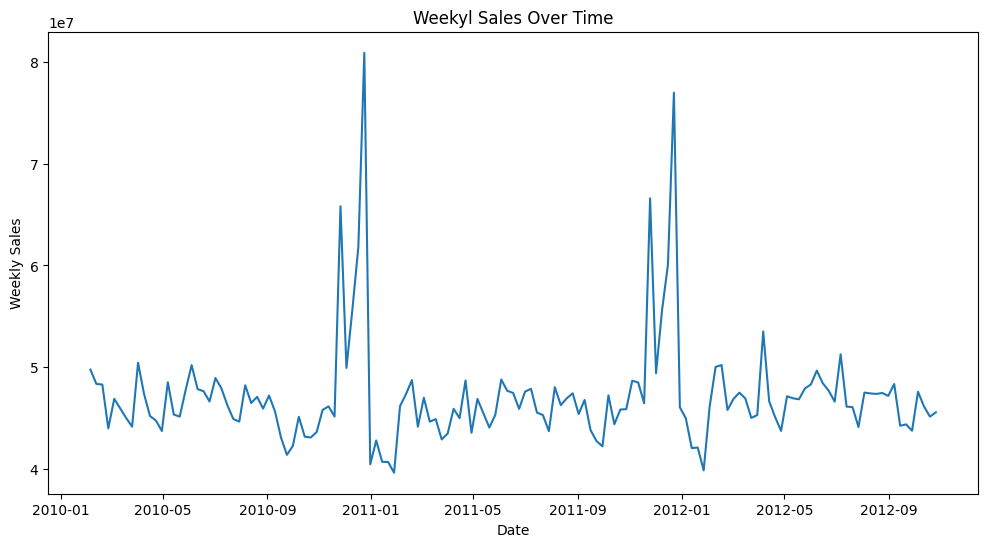

In [109]:
weekly_sales = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize= (12,6))
plt.plot(weekly_sales.index,weekly_sales.values)
plt.title("Weekyl Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()

Weekly sales were aggregated by date to examine the overall sales trend over time. 

This visualization helps identify long-term patterns, seasonal fluctuations, and unusual spikes that may affect forecasting performance.

## Feature Engineering

In [110]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week
df["Quarter"] = df["Date"].dt.quarter

Additional time-based features were created from the `Date` column to capture seasonal patterns and improve forecasting performance. These extracted features include year, month, week number, and quarter information.

# Feature Selection

In [111]:
X = df[[
    "Store",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Year",
    "Month",
    "Week",
    "Quarter"
]]

y = df["Weekly_Sales"]

The input features (`X`) include store information, holiday indicators, macroeconomic variables, and time-based features derived from the date column.
 The target variable (`y`) is `Weekly_Sales`, which represents the weekly sales values to be forecasted.

## Train-Test Split

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

The dataset was split into training and testing sets to evaluate the model’s ability to generalize to unseen data.

80% of the observations were used for training, while 20% were reserved for testing. A fixed random_state was applied to ensure reproducibility of the results.

## Initial XGBoost Model

In [113]:
model = XGBRegressor(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

XGBoost was selected for its strong performance on structured data and its ability to capture complex relationships, seasonal patterns, and feature interactions.

The algorithm is widely used in forecasting tasks due to its high predictive accuracy and flexibility.

An initial XGBoost regression model was built to predict weekly sales using store-level, macroeconomic, and time-based features.

The model parameters were chosen to balance predictive performance and model complexity.

## Model Training 

In [114]:
model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


The XGBoost model was trained on the training dataset to learn the relationships between the input features and weekly sales.

During this process, the algorithm identifies patterns and feature interactions that can be used to generate accurate sales forecasts.

## Model Prediction

In [115]:
y_pred = model.predict(X_test)

The trained model was used to generate predictions on the test dataset.

These predicted values will be compared with actual sales values to evaluate forecasting performance.

## Model Evaluation

In [116]:
mae = mean_absolute_error(y_test,y_pred)
print(f"MAE: {mae:,.2f}")

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print(f"RMSE: {rmse:,.2f}")

MAE: 59,128.40
RMSE: 94,826.46


The XGBoost model achieved strong forecasting performance, with relatively low MAE and RMSE values compared to the average weekly sales of approximately $1.05 million.

While prediction errors increase during sharp sales spikes and seasonal peaks, the model captures overall sales patterns effectively.

# Actual vs Predicted Sales Visualization

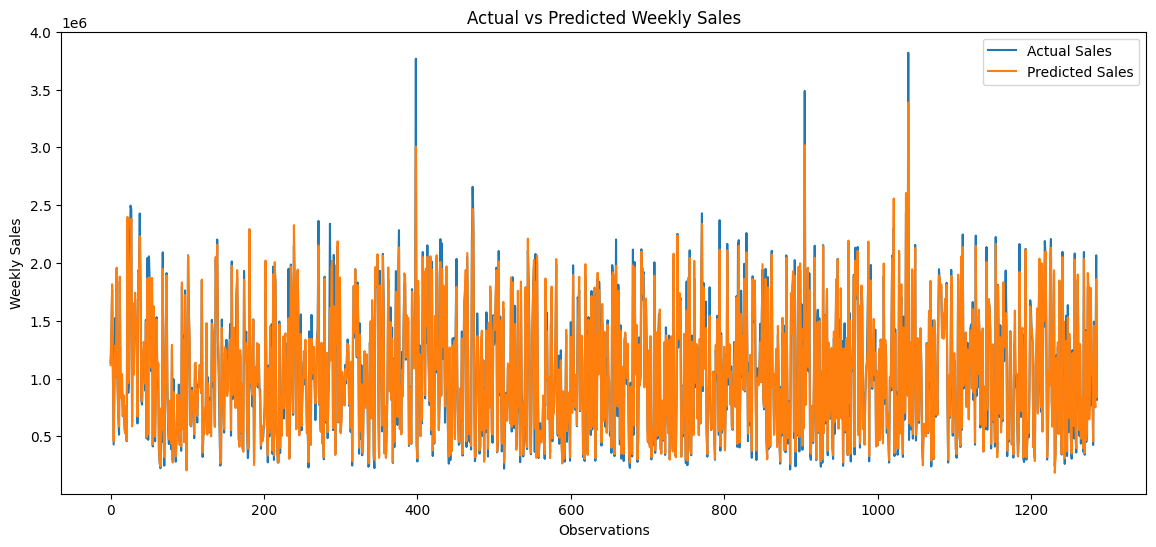

In [117]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

plt.figure(figsize=(14,6))
plt.plot(results["Actual"].values, label = "Actual Sales")
plt.plot(results["Predicted"].values, label = "Predicted Sales")

plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Observations")
plt.ylabel("Weekly Sales")
plt.legend()
plt.show()

The predicted values closely follow the actual sales trends, indicating that the XGBoost model effectively captures overall sales dynamics.
Minor deviations are mainly observed during extreme sales peaks and sudden fluctuations.

## Forecasting Dataset Preparation

In [118]:
sales_forecast = df.groupby("Date")["Weekly_Sales"].sum().reset_index()

sales_forecast["Year"] = sales_forecast["Date"].dt.year
sales_forecast["Month"] = sales_forecast["Date"].dt.month
sales_forecast["Week"] = sales_forecast["Date"].dt.isocalendar().week
sales_forecast["Quarter"] = sales_forecast["Date"].dt.quarter

A separate time series dataset was created by aggregating total weekly sales across all stores. Additional time-based features, including year, month, week number, and quarter, were generated to support forecasting experiments.

## Forecast Feature Engineering

Several forecasting-oriented features were created to improve the model’s ability to capture temporal patterns and sales dynamics.

In [119]:
sales_forecast["Lag_1"] = sales_forecast["Weekly_Sales"].shift(1)
sales_forecast["Lag_2"] = sales_forecast["Weekly_Sales"].shift(2)
sales_forecast["Lag_4"] = sales_forecast["Weekly_Sales"].shift(4)
sales_forecast["Lag_8"] = sales_forecast["Weekly_Sales"].shift(8)
sales_forecast["Lag_12"] = sales_forecast["Weekly_Sales"].shift(12)

sales_forecast["Rolling_Mean_2"] = (
    sales_forecast["Weekly_Sales"]
    .rolling(window=2)
    .mean()
)

sales_forecast["Rolling_Mean_4"] = (
    sales_forecast["Weekly_Sales"]
    .rolling(window=4)
    .mean()
)

sales_forecast["Rolling_Std_4"] = (
    sales_forecast["Weekly_Sales"]
    .rolling(window=4)
    .std()
)

holiday_info = df.groupby("Date")["Holiday_Flag"].max().reset_index()

sales_forecast = sales_forecast.merge(
    holiday_info,
    on="Date",
    how="left"
)

Feature engineering focused on capturing short-term temporal dependencies and seasonal patterns in weekly sales.

Lag-based features were created to incorporate historical sales information, while rolling averages and rolling standard deviation features were used to summarize recent trends and sales volatility. Holiday indicators were merged into the dataset to account for potential demand increases during special shopping periods.

Based on feature importance analysis, the most influential features were selected for the final forecasting model.

In [120]:
sales_forecast = sales_forecast.dropna()

Rows containing missing values introduced by lag and rolling window calculations were removed to ensure that the forecasting model was trained on complete observations only.

## Feature Importance Analysis

Feature importance analysis was performed to evaluate the contribution of lag, rolling, seasonal, and volatility-based variables to forecasting performance.

In [121]:
X = sales_forecast[[
    "Week",
    "Holiday_Flag",
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Lag_8",
    "Lag_12",
    "Rolling_Mean_2",
    "Rolling_Mean_4",
    "Rolling_Std_4"
    
]]

y = sales_forecast["Weekly_Sales"] 



split_index = int(len(sales_forecast)*0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

model = XGBRegressor(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

model.fit(X_train,y_train)

importance = model.feature_importances_
feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance


,Feature,Importance
0,Week,0.362068
7,Rolling_Mean_2,0.343750
2,Lag_1,0.130810
9,Rolling_Std_4,0.055358
5,Lag_8,0.043052
3,Lag_2,0.041333
6,Lag_12,0.009009
1,Holiday_Flag,0.008997
8,Rolling_Mean_4,0.003089
4,Lag_4,0.002534


Several lag-based and rolling statistical features were engineered to improve forecasting performance and capture temporal sales behavior.

The results showed that week number and short-term rolling averages were the most influential predictors, while lag features also contributed significantly to the model.

# Final Feature Selection and Forecast Model

MAE: 440872.4348148157
RMSE: 630118.5192471123


Text(0, 0.5, 'Weekly Sales')

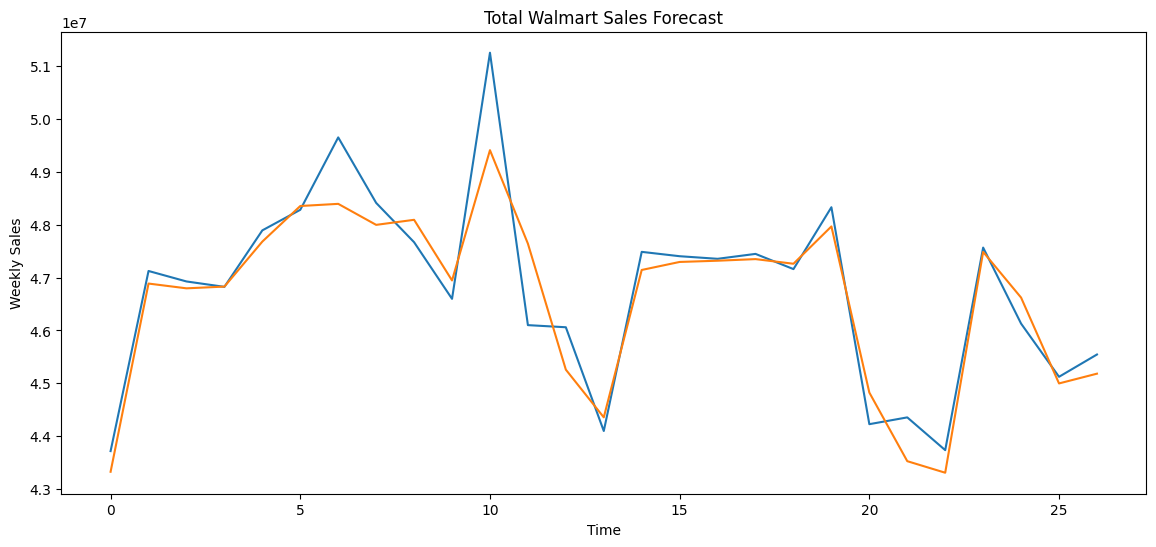

In [122]:
X = sales_forecast[[
    "Week",
   "Rolling_Mean_2",
    "Lag_1",
    "Rolling_Std_4",
    "Lag_8",
    "Lag_2"
    
]]

y = sales_forecast["Weekly_Sales"] 



split_index = int(len(sales_forecast)*0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

final_model = XGBRegressor(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = 42
)

final_model.fit(X_train,y_train)

y_pred = final_model.predict(X_test)

mae = mean_absolute_error(y_test,y_pred)

print("MAE:",mae)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE:", rmse)


plt.figure(figsize=(14,6))
plt.plot(y_test.values, label = "Actual Sales")
plt.plot(y_pred, label = "Predicted Sales")

plt.title("Total Walmart Sales Forecast")
plt.xlabel("Time")
plt.ylabel("Weekly Sales")

The final forecasting model was built using the most influential temporal, lag-based, and rolling statistical features identified through feature importance analysis.

The model achieved relatively low MAE and RMSE values compared to the overall scale of Walmart weekly sales, indicating strong predictive performance.

Week number and short-term rolling statistics emerged as the most important predictors, while lag-based variables helped capture temporal dependencies and recent sales behavior.

The forecast visualization shows that the model successfully captured overall sales trends and seasonal fluctuations, although minor deviations remained during sharp sales peaks and sudden demand changes.

## Forecast Validation Table

A validation table was created to compare actual and predicted sales values and to calculate forecast errors for individual observations.

In [123]:
final_results = pd.DataFrame({
    "Actual_Sales": y_test.values,
    "Predicted_Sales": y_pred
})

final_results["Error"] = (
    final_results["Actual_Sales"] - final_results["Predicted_Sales"]
)

final_results["Absolute_Error"] = abs(final_results["Error"])

final_results.head(10)

,Actual_Sales,Predicted_Sales,Error,Absolute_Error
0,43716798.89,43325752.0,391046.89,391046.89
1,47124197.93,46886148.0,238049.93,238049.93
2,46925878.99,46795964.0,129914.99,129914.99
3,46823939.22,46828776.0,-4836.78,4836.78
4,47892463.31,47680240.0,212223.31,212223.31
5,48281649.72,48353356.0,-71706.28,71706.28
6,49651171.78,48393964.0,1257207.78,1257207.78
7,48412110.70,47996484.0,415626.70,415626.70
8,47668284.97,48092128.0,-423843.03,423843.03
9,46597112.12,46945040.0,-347927.88,347927.88


The validation table provides a detailed view of model performance by showing the magnitude and direction of prediction errors for each forecasted observation.

# Future Weekly Sales Forecast

A future input dataset was manually constructed using the most recent observed values and rolling statistics to generate a one-step-ahead forecast for the next week.

In [124]:
future_data = pd.DataFrame({

    "Week": [44],
    "Rolling_Mean_2": [(45544116.29 + 45122410.57) / 2],
    "Lag_1": [45544116.29],
    "Rolling_Std_4":[np.std([ 45544116.29,45122410.57,46128514.25,47566639.31])],
    "Lag_8": [48330059.31],
    "Lag_2": [45122410.57]
    
        })

In [125]:
future_pred = final_model.predict(future_data)

print(f"Next Week Forecast: {future_pred[0]:,.2f}")

Next Week Forecast: 45,011,740.00


The final model predicts that Walmart's total weekly sales for the next period will be approximately **$45.0 million**.

This forecast is based on recent sales trends, seasonal timing, and short-term volatility captured through lag and rolling statistical features.

# Conclusion

This project explored Walmart weekly sales forecasting using XGBoost regression and time series feature engineering techniques.

Exploratory data analysis revealed clear seasonal patterns and fluctuations in weekly sales behavior. To improve forecasting performance, multiple temporal, lag-based, and rolling statistical features were generated from the time series data.

Feature importance analysis showed that short-term trends and recent historical sales information were the strongest drivers of predictive performance.

The final forecasting model achieved strong alignment between predicted and actual sales values, demonstrating the effectiveness of machine learning approaches for retail sales forecasting tasks.

A validation table comparing actual and predicted sales values was also created to examine forecast errors at the individual observation level.

The final model was also used to generate a one-step-ahead forecast, estimating next week's total Walmart sales at approximately $45.0 million.